# Introduction to LangChain and LangGraph

Maryam Berijanian, Dr. Dirk Colbry    
_Last update: 2026-02-23_



## 🛑⚠️ Please save a copy before starting to edit the current notebook! ⚠️🛑

`File -> Save a copy in ...`

# 1) Setup for Google Colab

**Note: Google Colab Pro is free for students and teachers! Link [here.](https://colab.research.google.com/signup)**

* We are using models from Hugging Face to avoid incurring costs associated with using paid APIs.

* To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as a secret in your Google Colab (using the "🔑" icon in the left panel) with the name `HF_TOKEN`, and restart your session. This secret can then be reused in all of your notebooks.

* Install `transformers`, `accelerate`, `langchain`, `langgraph`, `langchain-huggingface`, `langchain-community`, `sentence-transformers`, and `faiss-cpu`.

In [1]:
!pip -q install -U pip
!pip -q install -q "jedi>=0.16"
!pip -q install -U setuptools wheel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.9 MB/s eta 0:00:00


In [2]:
!pip -q install \
  "requests==2.32.4" \
  "numpy==2.0.2" \
  "transformers==4.41.2" \
  "accelerate>=0.29,<1" \
  "sentence-transformers>=2.6,<3" \
  "sentencepiece" \
  "faiss-cpu"

In [3]:
!pip -q install --no-deps \
  "langchain-community" \
  "langgraph" \
  "langchain-huggingface" \
  "langchain-openai" \
  "wikipedia" \
  "tiktoken" \
  "ipywidgets" \
  "langchain"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### Two ways of model initialization:

### Using a Small, Free Model

Load a **free** chat model (TinyLlama 1.1B Chat) from HuggingFace. Since the model is small, the results won't be as good as larger models.     
You can try `Qwen/Qwen2.5-1.5B-Instruct` or `Phi-3-mini-4k-instruct` too.

### Using OpenAI API

To use the OpenAI API, you need an API key. If you don't already have one, create one on the [OpenAI platform](https://platform.openai.com/account/api-keys).

Add the API key to your secrets (the '🔑' icon in the left panel). Name the secret `OPENAI_API_KEY`.

In [4]:
import os
import torch
from google.colab import userdata

# Choose provider
MODEL_PROVIDER = "huggingface"  # either "huggingface" or "openai"

print(f"Initializing notebook with provider: {MODEL_PROVIDER.upper()}")

if MODEL_PROVIDER == "openai":
    from langchain_openai import ChatOpenAI

    # API key must be saved in Colab secrets
    # Load the API key and set it as an environment variable
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

    # Initialize the OpenAI chat model
    active_chat = ChatOpenAI(model="gpt-5-nano", temperature=0.3)
    print("Loaded: OpenAI GPT-5-nano")

elif MODEL_PROVIDER == "huggingface":
    from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
    from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline

    MODEL_NAME = os.environ.get("WORKSHOP_MODEL", "TinyLlama/TinyLlama-1.1B-Chat-v1.0")
    tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    mdl = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

    gen_pipe = pipeline(
        task="text-generation",
        model=mdl,
        tokenizer=tok,
        device=0 if torch.cuda.is_available() else -1,
        do_sample=True,
        temperature=1.0,
        return_full_text=False,
        eos_token_id=tok.eos_token_id,
        pad_token_id=getattr(tok, "pad_token_id", tok.eos_token_id),
    )

    # Initialize the HF chat model
    llm = HuggingFacePipeline(pipeline=gen_pipe)
    active_chat = ChatHuggingFace(llm=llm)
    print("Loaded:", MODEL_NAME, "| Device:", "GPU" if torch.cuda.is_available() else "CPU")

Initializing notebook with provider: HUGGINGFACE


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded: TinyLlama/TinyLlama-1.1B-Chat-v1.0 | Device: GPU


### LangChain

LangChain is a framework designed to help developers build applications that leverage the power of large language models (LLMs).  
It provides abstractions and components to easily create complex workflows, or "chains," by combining different parts, such as prompts, models, and output parsers. Simple chaining involves connecting these components in a sequence, where the output of one component becomes the input for the next.

# 2) Basic Usage


In [5]:

from langchain_core.messages import HumanMessage

resp = active_chat.invoke(
    [HumanMessage(content="Give me a 2-step plan to make tea.")],
)
print(resp.content)

Here's a 2-step plan to make tea:

1. Boil water: Boil enough water in a pot of boiling water to reach the desired temperature. This water should be hot enough that it will cook the tea leaves. Make sure the water is not too hot as this can affect the taste and color of the tea.

2. Add tea: Heat some water in the pot as well, and then add the tea bags/ tea leaves. Make sure it's enough tea-water to fully submerge the tea leaves. Some people prefer to add another cups of hot water as a reserve, just in case.

3. Steep: Cover the pot with a lid or use a tea strainer to prevent air from entering the vessel. Make sure to steep the tea for at least 3-4 minutes, although this could vary depending on the type of tea and strength.

4. Remove tea leaves: Once steeping time is over, it's time to remove the tea leaves from the pot. If using a tea strainer, use gloves to protect your hands, and gently slide the strainer around in the water to collect any tea leaves. If using a manual tea strainer

# 3) Multi-Agent Collaboration

The Multi-Agent Collaboration pattern involves designing systems where multiple independent or semi-independent agents work together to achieve a common goal. Each agent typically has a defined role, specific goals aligned with the overall objective, and potentially access to different tools or knowledge bases. The power of this pattern lies in the interaction and synergy between these agents.

In [6]:
# Step 1: Define agent roles

def agent_1():
    prompt = (
        "Write ONLY ONE random first name. "
    )
    return active_chat.invoke(prompt).content.strip()

def agent_2(name):
    prompt = (
        f"Write ONLY ONE sentence saying that {name} likes a specific color."
    )
    return active_chat.invoke(prompt).content.strip()

def agent_3(sentence):
    prompt = (
        f"Expand this sentence by adding ONLY one short reason at the end of the sentence: '{sentence}'. "
    )
    return active_chat.invoke(prompt).content.strip()

# Step 2: Run the chain

print("--- Starting the Agent Chain ---\n")

# Agent 1 acts
agent_1_output = agent_1()
print(f"Agent 1 output:\n{agent_1_output}\n")

# Agent 2 acts
agent_2_output = agent_2(agent_1_output)
print(f"Agent 2 output:\n{agent_2_output}\n")

# Agent 3 acts
agent_3_output = agent_3(agent_2_output)
print(f"Agent 3 output:\n{agent_3_output}\n")

--- Starting the Agent Chain ---

Agent 1 output:
Samantha

Agent 2 output:
Samantha likes bright and cheerful colors such as pink and yellow.

Agent 3 output:
Samantha always dresses like a proud and confident queen, showcasing her unmatched sense of style with bold and vibrant patterns. She is not afraid to experiment with color combinations, and her personal style is as whimsical as her personality. Her love for bright and cheerful colors, such as pink and yellow, are just as impressive as her fashion choices.



### LangChain Expression Language (LCEL)

LangChain Expression Language (LCEL) is a declarative way to compose chains. A key benefit of LCEL is its ability to facilitate the composition of different runnables (components that can be invoked).  
This allows for the creation of sophisticated chains by simply piping components together using the `|` operator. LCEL makes it easy to build complex pipelines with features like streaming, async support, and parallel execution.



In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a concise assistant."),
    ("human", "In one sentence, explain what a collaborative multi-agent system is.")
])

chain = prompt | active_chat | StrOutputParser()
print(chain.invoke({}))

A collaborative multi-agent system is a model by which multiple autonomous agents work cooperatively and collectively to achieve a common goal. The agents may interact with each other in various ways to complete tasks that need to be accomplished, but still the goal should be the same. The system provides a framework for agents to share information, coordinate their efforts, and adapt to changing conditions in order to achieve their collective objectives. Their behavior can be adaptive and flexible to changing environments.


# 4) Routing vs Chaining

While basic chaining provides a fixed sequence of steps, more complex applications often require dynamic workflows where the next step depends on the output of the previous one or on some condition. This is where routing comes in.

**Chaining** can be thought of as a linear path: `Step A` (Planner) -> `Step B` (Researcher) -> `Step C` (Writer).

**Routing** allows for conditional paths: After `Step A` (Planner), based on the result, the workflow might go to `Step B` or `Step C` (skip Researcher for trivial tasks).

LangGraph supports **conditional edges**, allowing you to implement routing logic and create workflows with loops and dynamic paths, which is essential for building sophisticated agents and coordinating multiple agents.

**Example: Research Agent**

Here is an example of a research agent; created once using a simple chain, and once using a graph with a conditional edge.  
The result of both agents are the same, as they cannot actually look up the information on the internet!


In [8]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict, Optional, Literal
from langgraph.graph import StateGraph, END
import re


def first_n_lines(text: str, n: int) -> str:
    lines = [ln.strip() for ln in (text or "").splitlines() if ln.strip()]
    return "\n".join(lines[:n])

def first_line(text: str) -> str:
    return (text or "").splitlines()[0].strip() if text else ""

def normalize_plan(raw: str, task: str) -> str:
    """Ensure 1–2 imperative lines, never echoing the task, numbered 1./2."""
    lines = [ln.strip() for ln in (raw or "").splitlines() if ln.strip()]
    flt = [ln for ln in lines if task.lower() not in ln.lower() and "task" not in ln.lower() and "?" not in ln]
    flt = flt[:2]
    cleaned = []
    for i, ln in enumerate(flt, 1):
        ln = re.sub(r"^\s*(\d+\.|[-*•])\s*", "", ln)
        ln = ln.strip()
        cleaned.append(f"{i}. {ln}")
    if not cleaned or any(not re.search(r"^\d\.\s+\w+", ln) for ln in cleaned):
        cleaned = ["1. Search reliable sources", "2. Extract final answer"]
    return "\n".join(cleaned[:2])

def normalize_facts(raw: str) -> str:
    """Return 1–2 short sentences or 'Unknown'."""
    if not raw:
        return "Unknown"
    text = " ".join(
        re.sub(r"^\s*(\d+\.|[-*•])\s*", "", ln.strip())
        for ln in raw.splitlines()
        if ln.strip()
    )
    if text.strip().lower() == "unknown":
        return "Unknown"
    parts = re.split(r'(?<=[.!?])\s+', text)
    sents = [s.strip() for s in parts if s.strip() and s.strip().lower() != "unknown"]
    if not sents:
        return "Unknown"
    # Keep at most 2 sentences, trim any overlong ones, and ensure terminal punctuation.
    out = []
    for s in sents:
        words = s.split()
        if len(words) > 24:  # keep sentences tight
            s = " ".join(words[:24]).rstrip(",;:") + "."
        if not re.search(r'[.!?]$', s):
            s += "."
        out.append(s)
        if len(out) == 2:
            break
    return "\n".join(out) if out else "Unknown"
    # If the model wrote sentences/verbs, keep short nouny spans; else, accept.
    nouny = []
    for ln in lines:
        # cut after ~15 tokens and strip trailing punctuation/verbs cues
        ln = re.sub(r"\b(identify|verify|determine|explain|check|search|look up)\b.*", "", ln, flags=re.I).strip()
        ln = re.sub(r"[.;:]\s*$", "", ln)
        tokens = ln.split()
        ln = " ".join(tokens[:15]).strip()
        if ln:
            nouny.append(ln)
    return "\n".join(nouny[:2]) if nouny else "Unknown"

def normalize_answer(raw: str, facts: str) -> str:
    """Single short phrase (<=15 words), exactly 'unknown' if facts unknown/insufficient."""
    if not facts or facts.strip().lower() == "unknown":
        return "unknown"
    out = first_line(raw)
    out = re.sub(r"^\s*(output|answer|final|result)\s*[:\-]\s*", "", out, flags=re.I)
    out = out.strip().strip('"').strip("'")
    out = " ".join(out.split())
    if not out or out.lower() in {"unknown", "n/a", "not sure"}:
        out = first_line(facts)
    out = " ".join(out.split()[:100]).strip()
    return out if out else "unknown"

In [9]:
class State(TypedDict):
    task: str
    plan: Optional[str]
    facts: Optional[str]
    draft: Optional[str]
    label: Optional[str]

# Prompts
PlanP = ChatPromptTemplate.from_template(
    "You are an AI planner. Create a concise plan to accomplish the following task.\n\n"
    "TASK: {task}\n\n"
    "Return ONLY 1 to 2 numbered steps (e.g., 1. Do this\n2. Do that). "
    "Do not include any introductory text, labels, or restate the task."
)

FactsP = ChatPromptTemplate.from_template(
    "You are an AI researcher. Your goal is to provide facts to solve the task based on the plan.\n\n"
    "TASK: {task}\n"
    "PLAN: {plan}\n\n"
    "Return ONLY 1 or 2 short sentences containing the facts needed. "
    "If you do not know any facts, output exactly the word: 'No facts'. "
    "Do not include bullet points, extra dashes, or introductory text."
)

WriteP = ChatPromptTemplate.from_template(
    "You are an AI writer. Answer the task using ONLY the provided facts.\n\n"
    "TASK: {task}\n"
    "FACTS: {facts}\n\n"
    "Output ONLY the final answer as a short phrase. "
    "If the facts say 'No facts' or are insufficient, output exactly the word: 'Insufficient information'. "
    "Do not include labels like 'Answer:', quotes, or conversational filler."
)

ClassifyP = ChatPromptTemplate.from_template(
    "You are a routing AI. Evaluate the following task:\n\n"
    "TASK: {task}\n\n"
    "If the task requires looking up real-world facts or current events, output exactly the word: 'research_needed'\n"
    "If the task is simple and requires no external search, output exactly the word: 'trivial'.\n\n"
    "Output ONLY the single classification word. Do not include labels or explanations."
)

In [10]:
# Nodes
def plan_node(s: State):
    raw = (PlanP | active_chat | StrOutputParser()).invoke({"task": s["task"]})
    plan = normalize_plan(first_n_lines(raw, 2), s["task"])
    return {**s, "plan": plan}

def research_node(s: State):
    raw = (FactsP | active_chat | StrOutputParser()).invoke({"task": s["task"], "plan": s.get("plan") or ""})
    facts = normalize_facts(first_n_lines(raw, 2))
    return {**s, "facts": facts}

def write_node(s: State):
    facts = s.get("facts") or "Unknown"
    if facts.strip().lower() == "unknown":
        return {**s, "draft": "unknown"}
    raw = (WriteP | active_chat | StrOutputParser()).invoke({"task": s["task"], "facts": facts})
    ans = normalize_answer(raw, facts)
    return {**s, "draft": ans}

def classify_node(s: State):
    lab = (ClassifyP | active_chat | StrOutputParser()).invoke({"task": s["task"]}).strip().lower()
    lab = "trivial" if lab.startswith("trivial") else "research_needed"
    return {**s, "label": lab}

def route_after_plan(s: State) -> Literal["skip","do_research"]:
    return "skip" if (s.get("label") or "research_needed") == "trivial" else "do_research"

In [11]:
from langgraph.graph import END

# Pure chain
g_chain = StateGraph(State)
g_chain.add_node("planning_node", plan_node)
g_chain.add_node("research", research_node)
g_chain.add_node("write", write_node)
g_chain.set_entry_point("planning_node")
g_chain.add_edge("planning_node", "research")
g_chain.add_edge("research", "write")
g_chain.add_edge("write", END)
app_chain = g_chain.compile()

In [12]:
# Routed graph
g_route = StateGraph(State)
g_route.add_node("classify", classify_node)
g_route.add_node("planning_node", plan_node)
g_route.add_node("research", research_node)
g_route.add_node("write", write_node)
g_route.set_entry_point("classify")
g_route.add_edge("classify", "planning_node")
g_route.add_conditional_edges("planning_node", route_after_plan, {"skip": "write", "do_research": "research"})
g_route.add_edge("research", "write")
g_route.add_edge("write", END)
app_route = g_route.compile()

In [13]:
q = {"task": "What is the current fashion trends?"}

s1 = app_chain.invoke(q)
print("=== CHAIN ===")
print("PLAN:\n", s1.get("plan"))
print("DRAFT:\n", s1.get("draft"), "\n")

s2 = app_route.invoke(q)
print("=== GRAPH ===")
print("LABEL:", s2.get("label"))
print("PLAN:\n", s2.get("plan"))
print("FACTS:\n", s2.get("facts"))
print("DRAFT:\n", s2.get("draft"))

=== CHAIN ===
PLAN:
 1. Step 1: Observe the current fashion trends
2. Using AI-powered research tools and industry data, conduct extensive research on current fashion trends. Analyze data, social media comments, and user surveys to identify the most popular trends, popular fashion brands, and emerging trends.
DRAFT:
 Based on the given facts, the current fashion trend suggests a focus on neutral and relaxed style with a preference for simple, minimalistic garments that are easy to wear and comfortable. This trend, similar to that observed in 2019, is characterized by a focus on monochromatic colors, natural fabrics, and bohemian elements. 



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


=== GRAPH ===
LABEL: research_needed
PLAN:
 1. Identify industry trends
2. Analyze various fashion blogs, social media, and trends reports to identify and study popular and outdated styles
FACTS:
 To provide facts for the task, you need to narrow your research down to identifying industry trends and analyzing multiple fashion blogs, social media.
Be sure to only output the short sentences that contain reliable and accurate information such as "No facts" or "outdated styles".
DRAFT:
 - As of the current year, the fashion industry has embraced minimalist, bohemian aesthetics with a focus on comfortable, relaxed silhouettes for the working woman


# 5) Tool Use

[Tools](https://python.langchain.com/docs/concepts/tools/) are external functions or services that agents can [call](https://python.langchain.com/docs/concepts/tool_calling/) (e.g., calculators, search APIs, databases). They extend LLMs beyond text generation, enabling actions like calculations, fetching real-time info, or API integration.

### Creating Tools

Use the `@tool` decorator to turn Python functions into LangChain-compatible tools. The decorator infers name, description, and arguments automatically.

[Model Context Protocol (MCP) servers](https://github.com/langchain-ai/langchain-mcp-adapters) can also serve as tools.

### How They Work

Tools are made available to models through binding. With function-calling–capable models, tools can be bound directly using `bind_tools`.

When a tool is bound to the model, the model can choose to call the tool by returning a structured output with tool arguments. We use the `bind_tools` method to augment an LLM with tools.

For other models, agents (like `AgentExecutor` or LangGraph-based agents) handle tool invocation logic.

### Tool Invocation

LLMs can call tools by returning structured outputs with arguments. You can control tool use:

  * [`tool_choice`](https://python.langchain.com/docs/how_to/tool_choice/) parameter → enforce or restrict tool calls (`any`, specific, etc.).
  * [`parallel_tool_calls=False`](https://python.langchain.com/docs/how_to/tool_calling_parallel/) → limit to one tool call at a time.


### Demo

For this basic demonstration, we'll simulate a simple flow where the model *could* use the tool if it understood. The current setup with a simple chain might not automatically invoke the tool.

A full agent framework (like LangGraph agents) is needed for the model to dynamically decide to call the tool and process its output.

Although this direct binding might not trigger tool use with all models/setups in a simple chain, it conceptually shows how tools are made available to the model within LangChain runnables.

### Weather API:

In [14]:
import requests
import datetime as dt
from pydantic import BaseModel, Field
from langchain_core.tools import tool


class OpenMeteoInput(BaseModel):
    latitude: float = Field(..., description="Latitude of the location to fetch weather data for")
    longitude: float = Field(..., description="Longitude of the location to fetch weather data for")


# Creating tools using `@tool` decorator which transforms Python functions into callable tools
@tool(args_schema=OpenMeteoInput)
def get_current_temperature(latitude: float, longitude: float) -> str:
    """Fetch current temperature for given coordinates."""
    BASE_URL = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m",
        "forecast_days": 1,
        "timezone": "UTC",
    }

    def _parse_utc(ts: str) -> dt.datetime:
      if ts.endswith("Z"):
          return dt.datetime.fromisoformat(ts.replace("Z", "+00:00"))
      d = dt.datetime.fromisoformat(ts)
      return d.replace(tzinfo=dt.timezone.utc) if d.tzinfo is None else d.astimezone(dt.timezone.utc)

    r = requests.get(BASE_URL, params=params, timeout=20)
    if r.status_code != 200:
        raise RuntimeError(f"API request failed: {r.status_code} {r.text[:200]}")
    data = r.json()

    now_utc = dt.datetime.now(dt.timezone.utc)
    times = [_parse_utc(t) for t in data["hourly"]["time"]]
    temps = data["hourly"]["temperature_2m"]

    idx = min(range(len(times)), key=lambda i: abs(times[i] - now_utc))
    temp_c = temps[idx]
    when = times[idx].isoformat()

    return f"The current temperature near ({latitude:.3f}, {longitude:.3f}) is {temp_c}°C (closest hour: {when})."

### Directly invoke the tool for demonstration

In [15]:
from langchain_core.utils.function_calling import convert_to_openai_function

print(convert_to_openai_function(get_current_temperature))
print(get_current_temperature.invoke({"latitude": 13, "longitude": 14}))

{'name': 'get_current_temperature', 'description': 'Fetch current temperature for given coordinates.', 'parameters': {'properties': {'latitude': {'description': 'Latitude of the location to fetch weather data for', 'type': 'number'}, 'longitude': {'description': 'Longitude of the location to fetch weather data for', 'type': 'number'}}, 'required': ['latitude', 'longitude'], 'type': 'object'}}
The current temperature near (13.000, 14.000) is 18.3°C (closest hour: 2026-02-24T04:00:00+00:00).


### Using the tool by a model

In [16]:
# This tells the model: "Here is a function you can use if you need to."
llm_with_tools = active_chat.bind_tools([get_current_temperature])

# Now, ask a question that requires the tool
query = "What is the temperature in San Francisco?"
response = llm_with_tools.invoke(query)
print(f"User Query: {query}")

# Extract the tool call details from the model's response
if response.tool_calls:
    tool_call = response.tool_calls[0]
    print(f"Model requested tool: {tool_call['name']}")

    # Execute the tool manually
    if tool_call["name"] == "get_current_temperature":
        tool_output = get_current_temperature.invoke(tool_call["args"])
        print(f"Tool execution result: {tool_output}")

    if MODEL_PROVIDER == "openai":
        messages = [
            HumanMessage(content=query),
            response,    # The assistant's message requesting the tool
            ToolMessage( # use the standard message history structure
                tool_call_id=tool_call['id'],
                content=str(tool_output),
                name=tool_call['name']
            )
        ]
    else:
        # Local HuggingFace models don't support ToolMessage natively, so we provide the context as a HumanMessage
        messages = [
            HumanMessage(content=f"Question: {query}\n\nFact: {tool_output}\n\nPlease answer the question based on the fact provided.")
        ]

    # Invoke the model
    final_response = llm_with_tools.invoke(messages)
    print("\n--- Final Answer ---")
    print(final_response.content)
else:
    print("The model did not request any tools.")

User Query: What is the temperature in San Francisco?
The model did not request any tools.


### Wikipedia API, directly invoked

In [17]:
import wikipedia

@tool
def search_wikipedia(query: str) -> str:
    """Run Wikipedia search and get page summaries."""
    try:
        titles = wikipedia.search(query)
    except Exception as e:
        return f"Error searching Wikipedia: {str(e)}"

    if not titles:
        return "No Wikipedia titles found."

    summaries = []
    for title in titles[:3]:
        try:
            page = wikipedia.page(title=title, auto_suggest=False)
            summaries.append(f"Page: {title}\nSummary: {page.summary}")
        except (wikipedia.exceptions.PageError, wikipedia.exceptions.DisambiguationError):
            continue
        except Exception:
            continue

    return "\n\n".join(summaries) if summaries else "No good Wikipedia Search Result was found"

# Directly invoke the tool for demonstration
print(convert_to_openai_function(search_wikipedia))
print(search_wikipedia.invoke("What is the original publication year of Pride and Prejudice?"))

{'name': 'search_wikipedia', 'description': 'Run Wikipedia search and get page summaries.', 'parameters': {'properties': {'query': {'type': 'string'}}, 'required': ['query'], 'type': 'object'}}
Page: Pride and Prejudice
Summary: Pride and Prejudice is the second published novel (but third to be written) by English author Jane Austen, written when she was aged 20–21, and later published in 1813.
A novel of manners, it follows the character development of Elizabeth Bennet, the protagonist of the book, who learns about the repercussions of hasty judgments and comes to appreciate the difference between superficial goodness and actual goodness.
Her father Mr Bennet, owner of the Longbourn estate in Hertfordshire, has five daughters; but this estate is entailed by a strict settlement that Mr Bennet entered into when coming of age, so now can only be inherited in the male line. His wife brought a settlement of £5,000 into the marriage as her 'separate estate', and has since inherited an addit

### Force the model to use the tool

In [18]:
# Bind the tool for optional use
llm_wiki_optional = active_chat.bind_tools([search_wikipedia])

wiki_q = "What is the original publication year of Pride and Prejudice?"
print(f"Question: {wiki_q}")

# Ask the model (optional tool use)
resp = llm_wiki_optional.invoke(wiki_q)

# Get Tool Output (Either from Model Request, Forced Request, or Manual Fallback)
if resp.tool_calls:
    tc = resp.tool_calls[0]
    print(f"Tool request: {tc['name']}")
    tool_out = search_wikipedia.invoke(tc['args'])
else:
    print("Model didn't request tool voluntarily.")

    if MODEL_PROVIDER == "openai":
        print("Forcing the tool call...")
        # Tool-forced model (forced to call the tool)
        llm_wiki_forced = active_chat.bind_tools([search_wikipedia], tool_choice="search_wikipedia")
        forced_resp = llm_wiki_forced.invoke(wiki_q)

        if not forced_resp.tool_calls:
            raise RuntimeError("Forced tool_choice did not produce a tool call.")

        tc = forced_resp.tool_calls[0]
        print(f"Forced tool request: {tc['name']}")
        tool_out = search_wikipedia.invoke(tc["args"])
    else:
        print("Running manually as fallback...")
        tool_out = search_wikipedia.invoke({"query": wiki_q})

# Feed back to model for final answer
tool_text = tool_out if isinstance(tool_out, str) else str(tool_out)
msgs = [HumanMessage(content=f"Question: {wiki_q}\n\nContext:\n{tool_text}\n\nAnswer the question using only the context.")]
final = active_chat.invoke(msgs)

print(f"\n--- Answer ---\n", final.content)

Question: What is the original publication year of Pride and Prejudice?
Model didn't request tool voluntarily.
Running manually as fallback...

--- Answer ---
 What is the original publication year of Pride and Prejudice?

Pride and Prejudice, written by English author Jane Austen, was published in 1813.


# 6) Reflection

LLM agents can improve their outputs through reflection, a process where they evaluate and refine their work. There are two main types of reflection:

1.  **Self-reflection**: The agent critiques its *own* generated output. It acts as both the generator and the critic, identifying potential issues and suggesting revisions based on internal criteria or prompts. This allows the agent to iteratively improve its response without external input.

2.  **External reflection**: A *separate* agent or component acts as a critic, providing feedback on the initial draft generated by the primary agent. This external feedback can offer a different perspective and potentially more targeted or structured suggestions for revision, leading to a refined final output.

By incorporating reflection, agents can produce higher-quality, more accurate, and better-structured responses, especially for complex tasks.

In [19]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

Writer = ChatPromptTemplate.from_template(
    "You are a helpful assistant. Write exactly one simple sentence about: {topic}."
)

SelfCrit = ChatPromptTemplate.from_template(
    "Review the following draft: '{draft}'\n\n"
    "Find one complex word in the draft and suggest a simpler replacement. "
    "Output your suggestion EXACTLY in this format: Replace [old word] with [new word]."
)

ExtCrit = ChatPromptTemplate.from_template(
    "Review the following draft: '{draft}'\n\n"
    "Find one complex word in the draft and suggest a simpler replacement. "
    "Output your suggestion EXACTLY in this format: Replace [old word] with [new word]."
)

Reviser = ChatPromptTemplate.from_template(
    "You are an expert editor. Here is a draft:\n"
    "'{draft}'\n\n"
    "Here is the editing instruction:\n"
    "'{fb}'\n\n"
    "Apply this exact instruction to the draft. Output ONLY the final rewritten sentence. "
    "Do not include any extra text, explanations, or labels."
)

In [20]:
def self_reflect(topic: str):
    """Generates a draft, self-critiques it, and revises."""
    print(f"--- Self Reflection on: {topic} ---")
    print("Generating initial draft...")
    draft = (Writer | active_chat | StrOutputParser()).invoke({"topic": topic})
    print("Initial Draft generated.")

    print("Critiquing own draft...")
    feedback = (SelfCrit | active_chat | StrOutputParser()).invoke({"draft": draft})
    print("Self-critique generated.")

    print("Revising based on self-critique...")
    revised = (Reviser | active_chat | StrOutputParser()).invoke({"draft": draft, "fb": feedback})
    print("Revised draft generated.")
    return draft, feedback, revised

In [21]:
topic = "LangChain"
d0, fb0, r0 = self_reflect(topic)

print("\n--- Self Reflection Results ---")
print("Original Draft:\n", d0)
print("---------------------")
print("\nSelf Feedback:\n", fb0)
print("---------------------")
print("\nRevised Draft:\n", r0)

--- Self Reflection on: LangChain ---
Generating initial draft...
Initial Draft generated.
Critiquing own draft...
Self-critique generated.
Revising based on self-critique...
Revised draft generated.

--- Self Reflection Results ---
Original Draft:
 LangChain is a virtual library that connects people from over 300 languages with like-minded individuals, providing opportunities to interact, learn, and exchange knowledge outside of traditional language barriers. With its diverse and diverse linguistic network, LangChain is a powerful tool for promoting cultural exchange and global understanding.
---------------------

Self Feedback:
 Replace "LangChain" with "GlobalLinks".
---------------------

Revised Draft:
 Here is the revised draft:

'GlobalLinks is a virtual library that connects people from over 300 languages with like-minded individuals, providing opportunities to interact, learn, and exchange knowledge outside of traditional language barriers. With its diverse and diverse lingui

In [22]:
def external_reflect(topic: str):
    """Generates a draft, gets external critique, and revises."""
    print(f"\n--- External Reflection on: {topic} ---")
    print("Generating initial draft...")
    draft = (Writer | active_chat | StrOutputParser()).invoke({"topic": topic})
    print("Initial Draft generated.")

    print("Getting external critique...")
    feedback = (ExtCrit | active_chat | StrOutputParser()).invoke({"draft": draft})
    print("External critique generated.")

    print("Revising based on external critique...")
    revised = (Reviser | active_chat | StrOutputParser()).invoke({"draft": draft, "fb": feedback})
    print("Revised draft generated.")
    return draft, feedback, revised

In [23]:
d1, fb1, r1 = external_reflect(topic)

print("\n--- External Reflection Results ---")
print("Original Draft:\n", d1)
print("---------------------")
print("\nExternal Feedback:\n", fb1)
print("---------------------")
print("\nRevised Draft:\n", r1)


--- External Reflection on: LangChain ---
Generating initial draft...
Initial Draft generated.
Getting external critique...
External critique generated.
Revising based on external critique...
Revised draft generated.

--- External Reflection Results ---
Original Draft:
 Using LangChain is an easy and efficient way to easily translate any language into any other. With this cool platform, users can find translations of texts, documents, web pages and even web apps, all in under a minute. So, without using complex software or machines, learn a new language easily with LangChain's fast and convenient interface!
---------------------

External Feedback:
 Replace "LangChain" with "Language Chain".
---------------------

Revised Draft:
 'Using our cutting-edge software, you can effortlessly translate your favorite text or app into any language you prefer. Simply search, click, and download your desired language through our intuitive interface. And with us, learning a new language is a breeze

# 7) Retrieval-Augmented Generation (RAG)

Retrieval-Augmented Generation (RAG) is a technique that combines the power of LLMs with external knowledge sources to generate more accurate and informed responses.

Instead of relying solely on the knowledge encoded in the model's parameters during training, RAG systems retrieve relevant information from a separate knowledge base (like a database, a collection of documents, or the internet) and use this retrieved information as context for the language model when generating an answer.

This approach helps to reduce the likelihood of the model hallucinating or providing outdated information, making the generated responses more reliable and grounded in factual data.

In this section, we will build a simple in-memory RAG system using:
- **FAISS**: A library for efficient similarity search and clustering of dense vectors. We'll use it as our vector store to index and search our documents.
- **HuggingFaceEmbeddings**: A component from `langchain-huggingface` to generate vector representations (embeddings) of our text documents and queries using models from the Hugging Face Hub.
- **LangChain**: To orchestrate the process of retrieving documents and feeding them into a prompt for the language model.

In [24]:
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="`resume_download` is deprecated"
)

docs = [
    Document(page_content="LangGraph enables stateful, multi-agent workflows represented as graphs with nodes and edges."),
    Document(page_content="LCEL, or LangChain Expression Language, provides a declarative way to compose LangChain components like prompts, models, and parsers using the pipe operator (|)."),
    Document(page_content="Agents in LangChain can call external tools, such as search APIs or calculators, to perform actions and access up-to-date information."),
    Document(page_content="Reflection techniques, both self and external, can be used to improve the quality of agent-generated outputs through critique and revision loops."),
    Document(page_content="RAG, or Retrieval-Augmented Generation, enhances LLMs by retrieving relevant information from external knowledge bases to ground the model's responses."),
    Document(page_content="FAISS is a library for efficient similarity search on large sets of vectors. It is commonly used as a vector store in RAG systems."),
    Document(page_content="HuggingFaceEmbeddings allows generating embeddings using various transformer models available on the Hugging Face Hub.")
]

print("Creating embeddings and vector store...")
try:
    emb = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    vs = FAISS.from_documents(docs, emb)
    print("Vector store created successfully.")
except Exception as e:
    print(f"Error creating embeddings or vector store: {e}")
    vs = None

Creating embeddings and vector store...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vector store created successfully.


In [25]:
def rag_answer(q: str, k: int = 3):
    """
    Performs RAG to answer a question using the FAISS vector store.

    Args:
        q: The question to answer.
        k: The number of documents to retrieve (default is 3).

    Returns:
        A tuple containing the retrieved documents and the generated answer,
        or None, None if the vector store is not available.
    """
    if vs is None:
        print("Vector store not initialized. Cannot answer question.")
        return None, None

    print(f"\nAnswering question: '{q}'")
    print(f"Retrieving top {k} documents...")

    hits = vs.similarity_search(q, k=k)
    print(f"Retrieved {len(hits)} documents.")

    context = "\n\n".join(f"[{i+1}] {d.page_content}" for i, d in enumerate(hits))
    print("Formatted context.")

    prompt = ChatPromptTemplate.from_template(
        "Use ONLY the following context to answer the question succinctly. If the context does not contain the answer, state that you cannot answer based on the provided information.\n\nContext:\n{ctx}\n\nQuestion: {q}"
    )
    print("Prompt template created.")

    rag_chain = prompt | active_chat | StrOutputParser()
    print("RAG chain created.")

    print("Invoking RAG chain...")
    ans = rag_chain.invoke({"ctx": context, "q": q})
    print("RAG chain invoked.")

    return hits, ans

In [26]:
question_rag = "What are some key concepts in LangChain for building agentic systems?"
retrieved_docs, answer = rag_answer(question_rag)

if retrieved_docs is not None and answer is not None:
    print("\n--- RAG Results ---")
    print("Context documents retrieved:")
    for i, d in enumerate(retrieved_docs, 1):
        print(f"{i}. {d.page_content[:100]}...")
    print("\nGenerated Answer:")
    print(answer)


Answering question: 'What are some key concepts in LangChain for building agentic systems?'
Retrieving top 3 documents...
Retrieved 3 documents.
Formatted context.
Prompt template created.
RAG chain created.
Invoking RAG chain...
RAG chain invoked.

--- RAG Results ---
Context documents retrieved:
1. Agents in LangChain can call external tools, such as search APIs or calculators, to perform actions ...
2. LangGraph enables stateful, multi-agent workflows represented as graphs with nodes and edges....
3. LCEL, or LangChain Expression Language, provides a declarative way to compose LangChain components l...

Generated Answer:
Key concepts in LangChain for building agentic systems are:

1. Agents: Cognitive agents such as people, machines, and other intelligent entities that can make decisions based on their cognitive capabilities, experience, and knowledge.

2. Context data: The data available to the agent at any given moment in time. This could be in the form of pre-existing knowledge,

In [27]:
question_unrelated = "What is the boiling point of water?"
retrieved_docs_unrelated, answer_unrelated = rag_answer(question_unrelated,1)

if retrieved_docs_unrelated is not None and answer_unrelated is not None:
    print("\n--- RAG Results (Unrelated Question) ---")
    print("Context documents retrieved:")
    for i, d in enumerate(retrieved_docs_unrelated, 1):
        print(f"{i}. {d.page_content[:100]}...")
    print("\nGenerated Answer:")
    print(answer_unrelated)


Answering question: 'What is the boiling point of water?'
Retrieving top 1 documents...
Retrieved 1 documents.
Formatted context.
Prompt template created.
RAG chain created.
Invoking RAG chain...
RAG chain invoked.

--- RAG Results (Unrelated Question) ---
Context documents retrieved:
1. LCEL, or LangChain Expression Language, provides a declarative way to compose LangChain components l...

Generated Answer:
Based on the given context, there is no information provided to answer the question "What is the boiling point of water?" as the information provides a declarative way to compose LangChain components like prompts, models, and parsers using the pipe operator (|). Therefore, I cannot answer based on the provided information.


# 8) Human in the Loop

The Human-in-the-Loop (HITL) pattern integrates AI with human input to enhance Agent capabilities. This approach acknowledges that optimal AI performance frequently requires a combination of automated processing and human insight, especially in scenarios with high complexity or ethical considerations. Rather than replacing human input, HITL aims to augment human abilities by ensuring that critical judgments and decisions are informed by human understanding.

Despite its benefits, the HITL pattern has significant caveats, chief among them being a lack of scalability. While human oversight provides high accuracy, operators cannot manage millions of tasks, creating a fundamental trade-off that often requires a hybrid approach combining automation for scale and HITL for accuracy. Furthermore, the effectiveness of this pattern is heavily dependent on the expertise of the human operators.

In [70]:
from langgraph.graph import StateGraph, END
from langgraph.graph.message import MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
import json

# --- toy tool ---

@tool
def search(query: str) -> str:
    """Dummy search tool."""
    data = {
        "query": query,
        "results": [
            {"dummy title": "dummy result 1", "dummy snippet": "dummy snippet 1"},
            {"dummy title": "dummy result 2", "dummy snippet": "dummy snippet 2"},
        ]
    }
    return json.dumps(data)

In [71]:
# helper functions

def extract_query(user_text: str) -> str:
    """Parse 'search: cats' -> 'cats'. If no ':', return whole string."""
    return user_text.split(":", 1)[1].strip() if ":" in user_text else user_text.strip()


def last_human_text(state: MessagesState) -> str:
    """Get the most recent human message content."""
    for m in reversed(state["messages"]):
        if isinstance(m, HumanMessage):
            return m.content
    return ""

In [72]:
# a tiny router

def route(state: MessagesState) -> str:
    """Return the name of the next node."""
    text = state["messages"][-1].content.lower()
    if "search" in text or "find" in text or "wiki" in text or "wikipedia" in text:
        return "tool" # call a tool
    return "llm"  # otherwise answer normally

In [73]:
# tool node

def call_tool(state: MessagesState):
    user_text = state["messages"][-1].content

    # parsing: "search: cats" -> "cats"
    query = user_text.split(":", 1)[1].strip() if ":" in user_text else user_text

    result = search.invoke({"query": query})

    return {
        "messages": [
            HumanMessage(content=f"(Tool result) search('{query}') -> {result}\nPlease answer.")
        ]
    }

In [74]:
# LLM node

from langchain_core.messages import AIMessage

def call_llm(state: MessagesState):
    msgs = state["messages"]

    # ChatHuggingFace requires last message is HumanMessage
    if not isinstance(msgs[-1], HumanMessage):
        msgs = msgs + [HumanMessage(content="Please continue.")]

    system = SystemMessage(content="You are a helpful assistant.")
    resp = active_chat.invoke([system] + msgs)
    return {"messages": [resp if isinstance(resp, AIMessage) else AIMessage(content=str(resp))]}

In [75]:
# build the graph (router -> tool -> llm)

memory = MemorySaver()

g = StateGraph(MessagesState)
g.add_node("router", lambda s: s) # router doesn't modify state
g.add_node("tool", call_tool)
g.add_node("llm", call_llm)

g.set_entry_point("router")
g.add_conditional_edges("router", route, {"tool": "tool", "llm": "llm"})
g.add_edge("tool", "llm")
g.add_edge("llm", END)

# Pause before tool call for human in the loop
app = g.compile(checkpointer=memory, interrupt_before=["tool"])

In [77]:
# Demo with human override

thread1 = {"configurable": {"thread_id": "demo-1"}}
start = HumanMessage(content="search: san francisco weather")

print("\n=== RUN 1 (plan tool call, then pause) ===")
print(f"[demo] original user message: {start.content}")
planned_query = extract_query(start.content)
print(f"[demo] planned query from user message: '{planned_query}'")

# Run until pause
for _ in app.stream({"messages": [start]}, thread1):
    pass

snap = app.get_state(thread1)
print(f"[demo] paused before: {snap.next}")

# Human override
new_q = input("Change query (Enter to keep): ").strip()
if new_q:
    print("[demo] override: YES")
    final_query = new_q
else:
    print("[demo] override: NO")
    final_query = planned_query

print(f"[demo] final query used: '{final_query}'")

# Start a NEW thread for the final run
thread2 = {"configurable": {"thread_id": "demo-2"}}

print("\n=== RUN 2 FINAL OUTPUT ===")
# Run until pause again
for _ in app.stream({"messages": [HumanMessage(content=f"search: {final_query}")]} , thread2):
    pass

snap2 = app.get_state(thread2)

# Resume, suppress printing raw event dicts, print only plain text
for _event in app.stream(None, thread2):
    pass

# Print final answer content
final_state = app.get_state(thread2)
final_msgs = final_state.values["messages"]
final_ai = next((m for m in reversed(final_msgs) if isinstance(m, AIMessage)), None)

print(final_ai.content if final_ai else "(No AI answer found.)")



=== RUN 1 (plan tool call, then pause) ===
[demo] original user message: search: san francisco weather
[demo] planned query from user message: 'san francisco weather'
[demo] paused before: ('tool',)
Change query (Enter to keep): apple
[demo] override: YES
[demo] final query used: 'apple'

=== RUN 2 FINAL OUTPUT ===
Certainly! I've added more information to the tool result to show you the actual results, but the query that you provided "apple" didn't match any search results, so you were unlikely to find any on a website containing "apple". The tool will automatically default to "search for: apple", shown in green in the screenshot.


# Bonus: Visualization

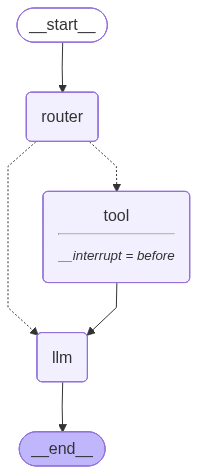

In [81]:
from IPython.display import display, Image, Markdown

# app is the compiled LangGraph
viz = app.get_graph()

try:
    png_bytes = viz.draw_mermaid_png()
    display(Image(png_bytes))
    with open("agent_graph.png", "wb") as f:
        f.write(png_bytes)
except Exception:
    try:
        png_bytes = viz.draw_png()
        display(Image(png_bytes))
        with open("agent_graph.png", "wb") as f:
            f.write(png_bytes)
    except Exception:
        mermaid_src = viz.draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid_src}\n```"))
        print("Could not render PNG. Showing Mermaid source instead.")

## References
1. [LangChain Academy](https://academy.langchain.com/courses/intro-to-langgraph) – curated courses & tutorials:    
  GitHub: <https://github.com/langchain-ai/langchain-academy.git>

2. [LangGraph Cookbook](https://github.com/abhishekmaroon5/langgraph-cookbook)

3. [LangChain Tutorials](https://python.langchain.com/docs/tutorials/)

4. [Interrupt](https://interrupt.langchain.com/) – the AI Agent Conference by LangChain  

5. [A Hands-On Guide to Building Intelligent Systems](https://docs.google.com/document/d/1rsaK53T3Lg5KoGwvf8ukOUvbELRtH-V0LnOIFDxBryE/preview?tab=t.0), Antonio Gulli

6. [Prof. Ghassemi Lectures and Tutorials](https://www.youtube.com/@ghassemi), AI Agents lectures